# Лабораторная работа 5. Задача регрессии

## Цель работы

Восстановить регрессионную зависимость по зашумленным данным. Генерируем два набора данных (почти линейный и сильно нелинейный), строим линейную и полиномиальную регрессию (степени 1-5) и обучаем ее разными методами: аналитическим решением, SGD, mini-batch, Гаусса-Ньютона и Левенберга-Марквардта. Исследуем влияние размера batch и регуляризации (L1, L2, Elastic Net).

Реализация - в `functions.py` (данные, признаки, задача) и `optimizers.py` (методы).

## Модель и потери

Полиномиальная регрессия степени `d`: предсказание `ŷ = w₀ + w₁·xn + … + w_d·xn^d`, где `xn` - это `x`, сжатый в `[-1,1]` (нормировка убирает плохую обусловленность). Линейная регрессия - это `d=1`.

Эмпирический риск (MSE): `Q(w) = (1/m)·Σ(ŷ(xᵢ) − yᵢ)²`. Полная функция потерь с регуляризацией: `L(w) = Q(w) + λ₁‖w‖₁ + λ₂‖w‖²₂` (свободный коэффициент `w₀` не регуляризуем; модуль в L1 сглажен `‖w‖₁ ≈ Σ√(wᵢ²+ε)`).

## Методы

- **Аналитика** - точное решение МНК через нормальные уравнения `w = (ΦᵀΦ)⁻¹Φᵀy` (для степени 1 = оценка через средние). При L2 - гребневая регрессия.
- **SGD** - градиент по одной случайной точке за шаг; **mini-batch** - по подвыборке размера `batch`. Шаг `w ← w − lr·∇`.
- **Гаусс-Ньютон** - для МНК: `(JᵀJ)Δw = −Jᵀr`, где `J = Φ`. Модель линейна по `w`, поэтому сходится за 1-2 шага (= метод Ньютона).
- **Левенберг-Марквардт** - Гаусс-Ньютон с регуляризацией `(JᵀJ + μI)Δw = −Jᵀr`; `μ` уменьшается при удачном шаге и растет при неудачном.

In [1]:
%matplotlib inline
import time
import numpy as np
import matplotlib.pyplot as plt
import functions as F
import optimizers as O

## Данные

Два набора по 120 точек на `x ∈ [-3, 3]` с нормальным шумом:
- **почти линейная:** `f = x + 0.5 + 0.1·sin(3x)`, `σ = 0.3`;
- **сильно нелинейная:** `f = sin(1.5x) + 0.3x + 2·exp(−(x−1)²)`, `σ = 0.4`.

почти линейная: f = x + 0.5 + 0.1 sin(3x), sigma=0.30
сильно нелинейная: f = sin(1.5x) + 0.3x + 2 exp(-(x-1)^2), sigma=0.40


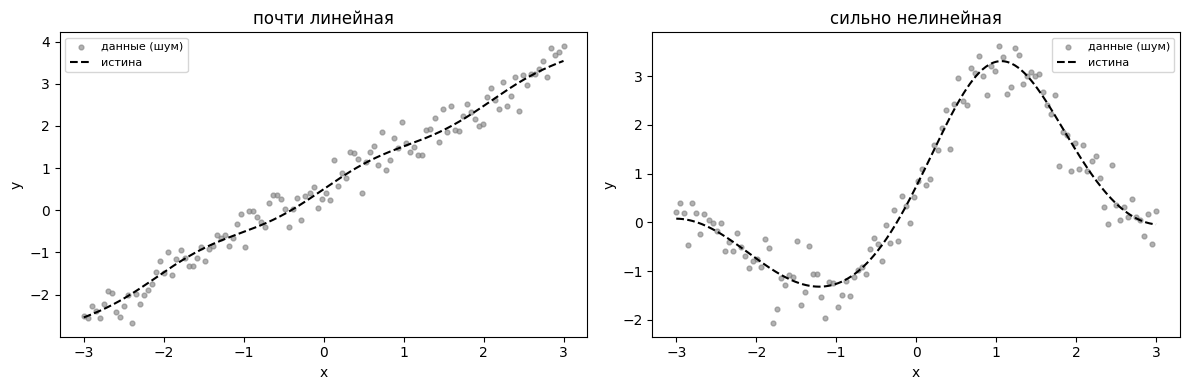

In [2]:
xL, yL, fL, nameL = F.make_linear_data()
xN, yN, fN, nameN = F.make_nonlinear_data()
print(nameL); print(nameN)

xs = np.linspace(-3, 3, 300)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (x, y, ft, nm) in zip(axes, [(xL, yL, fL, "почти линейная"), (xN, yN, fN, "сильно нелинейная")]):
    ax.scatter(x, y, s=12, color="gray", alpha=0.6, label="данные (шум)")
    ax.plot(xs, ft(xs), "k--", linewidth=1.5, label="истина")
    ax.set_title(nm); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Вспомогательные функции

In [3]:
DEGREES = [1, 2, 3, 4, 5]

def fnum(v, d=4):
    return f"{v:.{d}g}"

def print_table(title, headers, rows):
    print("\n" + title)
    cols = list(zip(*([headers] + rows)))
    w = [max(len(str(c)) for c in col) for col in cols]
    def fmt(r):
        return " | ".join(str(c).ljust(w[i]) for i, c in enumerate(r))
    print(fmt(headers))
    print("-+-".join("-" * x for x in w))
    for r in rows:
        print(fmt(r))

def fit_plot(x, y, ftrue, curves, title):
    g = np.linspace(x.min(), x.max(), 300)
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    ax.scatter(x, y, s=12, color="gray", alpha=0.5, label="данные")
    ax.plot(g, ftrue(g), "k--", linewidth=1.6, label="истина")
    for label, ys in curves:
        ax.plot(g, ys, linewidth=1.7, label=label)
    ax.set_title(title); ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

def loss_plot(title, series, xlabel="эпоха"):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for label, h in series:
        ax.plot(range(len(h)), h, label=label)
    ax.set_yscale("log"); ax.set_xlabel(xlabel); ax.set_ylabel("loss")
    ax.set_title(title); ax.grid(True, which="both", linewidth=0.3)
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

def train_all(x, y, degree, l1=0.0, l2=0.0, w0=None,
              sgd_lr=0.02, mb_lr=0.2, mb_batch=16, epochs=300):
    """Обучить все методы на свежих задачах. Возвращает dict результатов и norm."""
    Phi, norm = F.make_features(x, degree)
    if w0 is None:
        w0 = np.zeros(degree + 1)
    out = {}
    out["analytic"] = O.analytic(F.RegressionTask(Phi, y, l1, l2))
    out["SGD"] = O.sgd(F.RegressionTask(Phi, y, l1, l2), w0, epochs=epochs, lr=sgd_lr)
    out["mini-batch"] = O.minibatch_gd(F.RegressionTask(Phi, y, l1, l2), w0,
                                       epochs=epochs, batch=mb_batch, lr=mb_lr)
    out["Gauss-Newton"] = O.gauss_newton(F.RegressionTask(Phi, y, l1, l2), w0)
    out["LM"] = O.levenberg_marquardt(F.RegressionTask(Phi, y, l1, l2), w0)
    return out, norm

## Пункт 1. Базовые модели (без регуляризации)

Для обеих задач: аппроксимация полиномами степеней 1-5 (аналитика), затем на одной выбранной степени - обучение всеми методами, динамика loss и сравнение итогового риска.

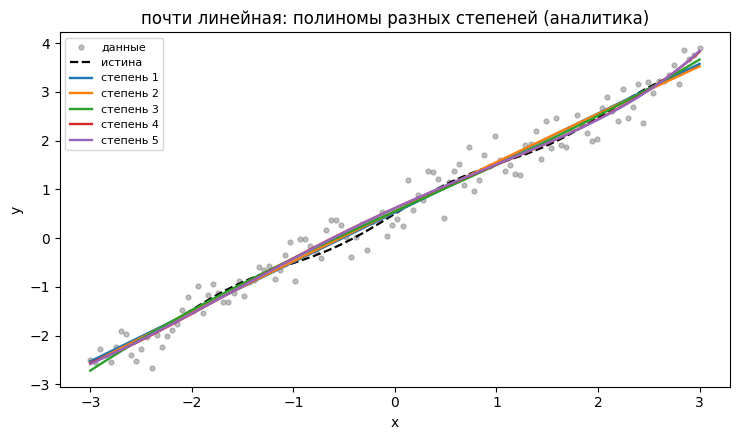

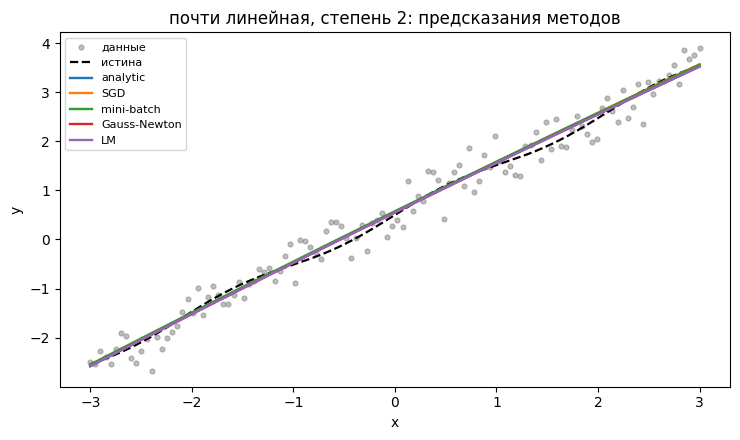

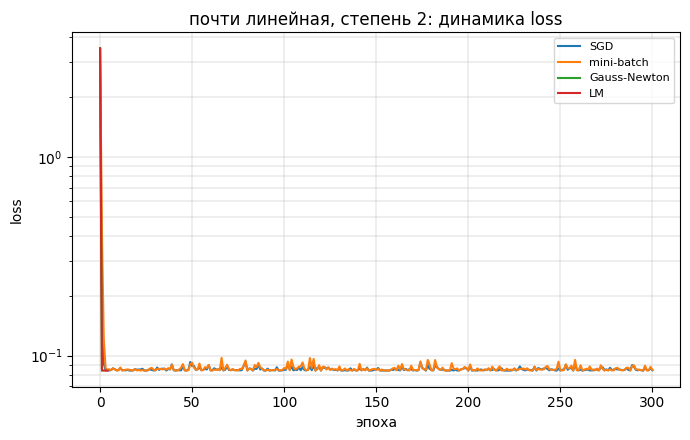


почти линейная, степень 2: итоговый риск Q
метод        | Q       | эпох/итер | ng    | статус  
-------------+---------+-----------+-------+---------
analytic     | 0.08402 | 0         | 0     | analytic
SGD          | 0.08437 | 300       | 36000 | epochs  
mini-batch   | 0.08481 | 300       | 2400  | epochs  
Gauss-Newton | 0.08402 | 1         | 2     | grad    
LM           | 0.08402 | 4         | 5     | grad    


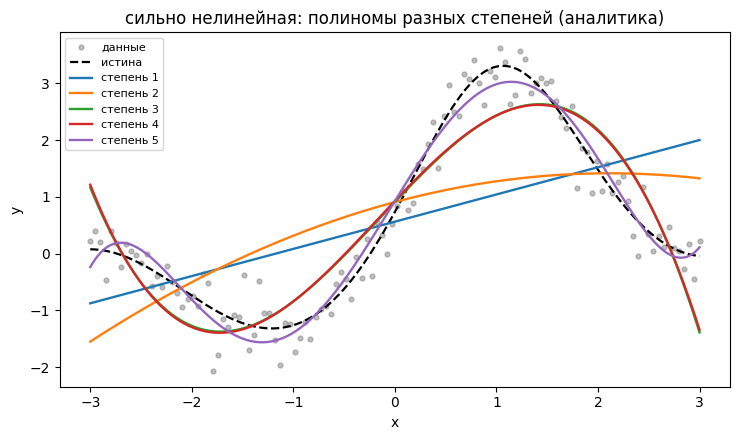

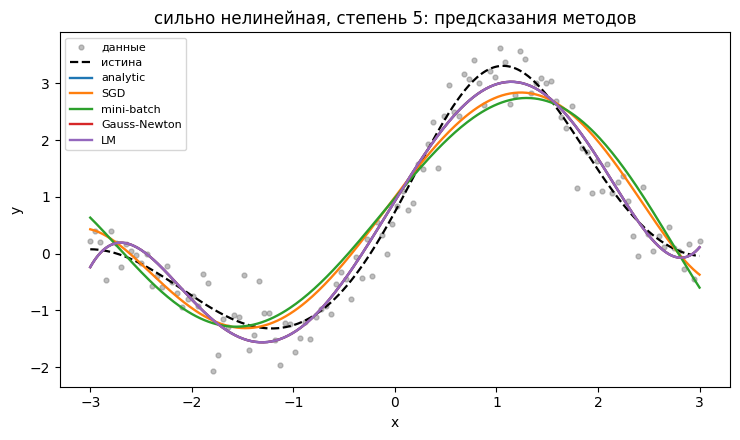

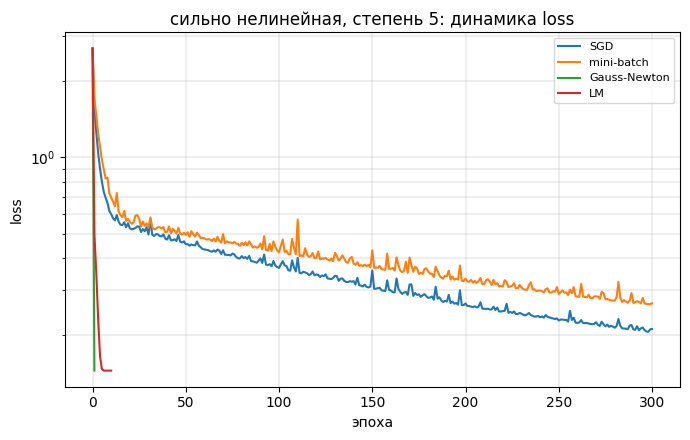


сильно нелинейная, степень 5: итоговый риск Q
метод        | Q      | эпох/итер | ng    | статус  
-------------+--------+-----------+-------+---------
analytic     | 0.145  | 0         | 0     | analytic
SGD          | 0.2113 | 300       | 36000 | epochs  
mini-batch   | 0.2665 | 300       | 2400  | epochs  
Gauss-Newton | 0.145  | 1         | 2     | grad    
LM           | 0.145  | 10        | 11    | grad    


In [4]:
for x, y, ftrue, name, rep in [(xL, yL, fL, "почти линейная", 2),
                                (xN, yN, fN, "сильно нелинейная", 5)]:
    # аппроксимация разными степенями
    curves = []
    for d in DEGREES:
        Phi, norm = F.make_features(x, d)
        w = O.analytic(F.RegressionTask(Phi, y))["w"]
        curves.append((f"степень {d}", F.predict_curve(np.linspace(x.min(), x.max(), 300), w, d, norm)))
    fit_plot(x, y, ftrue, curves, f"{name}: полиномы разных степеней (аналитика)")

    # все методы на выбранной степени
    res, norm = train_all(x, y, rep)
    curves = [(m, F.predict_curve(np.linspace(x.min(), x.max(), 300), res[m]["w"], rep, norm))
              for m in ["analytic", "SGD", "mini-batch", "Gauss-Newton", "LM"]]
    fit_plot(x, y, ftrue, curves, f"{name}, степень {rep}: предсказания методов")
    loss_plot(f"{name}, степень {rep}: динамика loss",
              [(m, res[m]["loss_hist"]) for m in ["SGD", "mini-batch", "Gauss-Newton", "LM"]])
    rows = [[m, fnum(res[m]["risk_hist"][-1]), res[m].get("epochs", res[m].get("iters", 0)),
             res[m]["ng"], res[m]["status"]] for m in ["analytic", "SGD", "mini-batch", "Gauss-Newton", "LM"]]
    print_table(f"{name}, степень {rep}: итоговый риск Q",
                ["метод", "Q", "эпох/итер", "ng", "статус"], rows)

## Пункт 2. Влияние размера batch

Нелинейная задача, полином степени 5. Mini-batch с разными размерами batch (1=SGD, …, m=полный градиент). Динамика loss по эпохам и по числу вычислений градиента + сравнение.

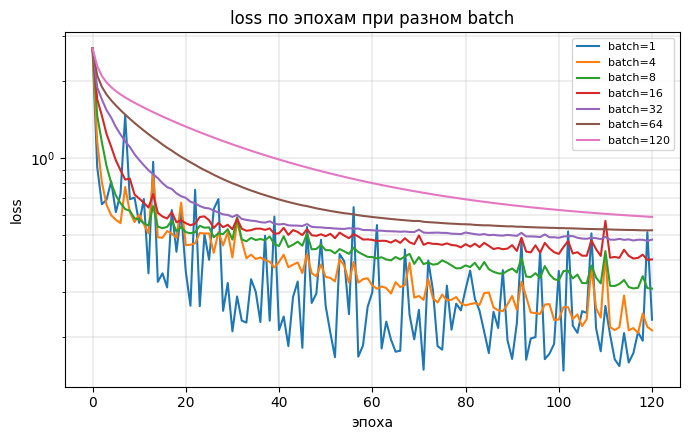

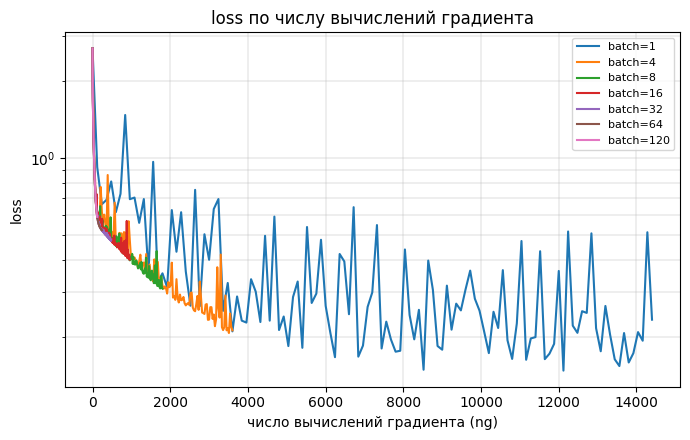


Влияние batch (нелинейная, степень 5, lr=0.2)
batch | эпох | ng    | loss итог | статус
------+------+-------+-----------+-------
1     | 120  | 14400 | 0.2344    | epochs
4     | 120  | 3600  | 0.213     | epochs
8     | 120  | 1800  | 0.3097    | epochs
16    | 120  | 960   | 0.4025    | epochs
32    | 120  | 480   | 0.4807    | epochs
64    | 120  | 240   | 0.5228    | epochs
120   | 120  | 120   | 0.5894    | epochs


In [5]:
Phi, norm = F.make_features(xN, 5)
batches = [1, 4, 8, 16, 32, 64, len(xN)]
by_epoch = []; by_ng = []; rows = []
for bs in batches:
    r = O.minibatch_gd(F.RegressionTask(Phi, yN), np.zeros(6), epochs=120, batch=bs, lr=0.2)
    by_epoch.append((f"batch={bs}", r["loss_hist"]))
    by_ng.append((f"batch={bs}", r["ng_hist"], r["loss_hist"]))
    rows.append([bs, r["epochs"], r["ng"], fnum(r["loss_hist"][-1]), r["status"]])
loss_plot("loss по эпохам при разном batch", by_epoch, "эпоха")

fig, ax = plt.subplots(figsize=(7, 4.5))
for label, ngh, lh in by_ng:
    ax.plot(ngh, lh, label=label)
ax.set_yscale("log"); ax.set_xlabel("число вычислений градиента (ng)"); ax.set_ylabel("loss")
ax.set_title("loss по числу вычислений градиента"); ax.grid(True, which="both", linewidth=0.3)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print_table("Влияние batch (нелинейная, степень 5, lr=0.2)",
            ["batch", "эпох", "ng", "loss итог", "статус"], rows)

## Пункт 3. Регуляризация

Нелинейная задача, полином высокой степени (переобучение). Сравниваем модель без регуляризации с L1, L2 и Elastic Net: предсказания, динамика loss/риска/регуляризатора, абсолютные значения коэффициентов.

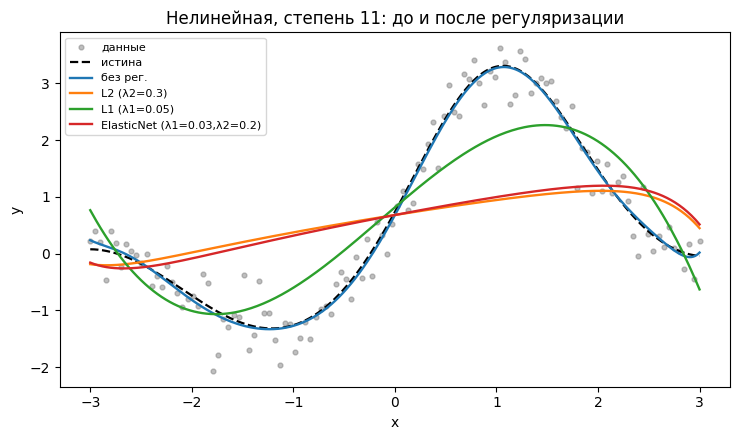

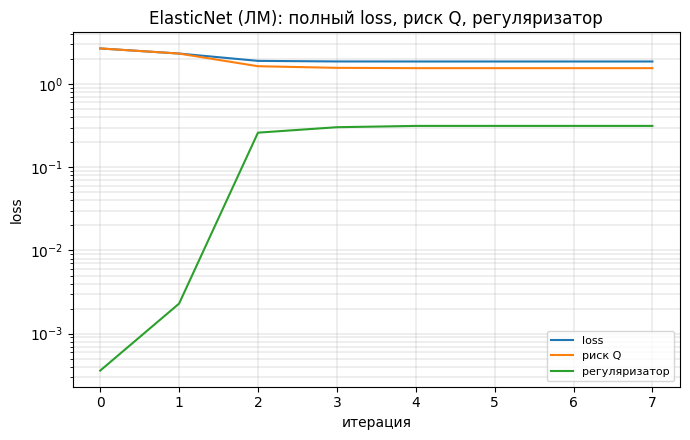

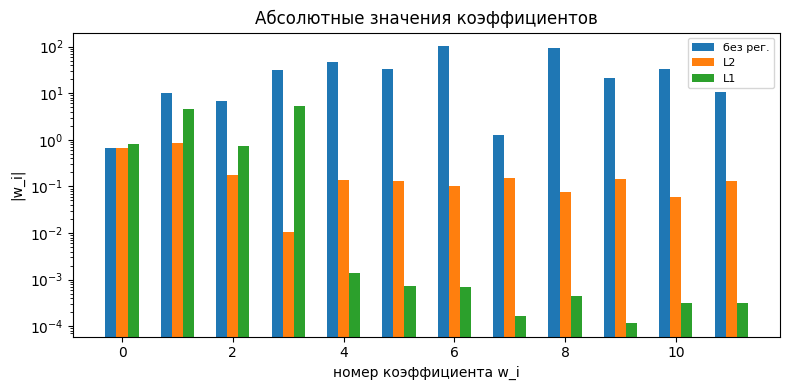


Регуляризация: риск и нормы коэффициентов (без w0)
модель                      | риск Q | ||w||_1 | ||w||_2
----------------------------+--------+---------+--------
без рег.                    | 0.1122 | 387.8   | 158.4  
L2 (λ2=0.3)                 | 1.641  | 1.967   | 0.9379 
L1 (λ1=0.05)                | 0.468  | 10.64   | 7.047  
ElasticNet (λ1=0.03,λ2=0.2) | 1.55   | 2.214   | 1.112  


In [6]:
deg = 11
Phi, norm = F.make_features(xN, deg)
g = np.linspace(xN.min(), xN.max(), 300)

# без регуляризации (переобучение)
w_over = O.analytic(F.RegressionTask(Phi, yN))["w"]

# регуляризованные модели (L1/EN - через ЛМ со сглаженным модулем, L2 - аналитика)
variants = [
    ("L2 (λ2=0.3)", dict(l2=0.3)),
    ("L1 (λ1=0.05)", dict(l1=0.05)),
    ("ElasticNet (λ1=0.03,λ2=0.2)", dict(l1=0.03, l2=0.2)),
]
models = {"без рег.": w_over}
for label, kw in variants:
    if kw.get("l1", 0) == 0:
        w = O.analytic(F.RegressionTask(Phi, yN, **kw))["w"]
    else:
        w = O.levenberg_marquardt(F.RegressionTask(Phi, yN, **kw), np.zeros(deg + 1))["w"]
    models[label] = w

fit_plot(xN, yN, fN, [(lab, F.predict_curve(g, w, deg, norm)) for lab, w in models.items()],
         f"Нелинейная, степень {deg}: до и после регуляризации")

# динамика loss/risk/reg для ElasticNet
t = F.RegressionTask(Phi, yN, l1=0.03, l2=0.2)
r = O.levenberg_marquardt(t, np.zeros(deg + 1))
loss_plot("ElasticNet (ЛМ): полный loss, риск Q, регуляризатор",
          [("loss", r["loss_hist"]), ("риск Q", r["risk_hist"]), ("регуляризатор", r["reg_hist"])], "итерация")

# коэффициенты по модулю
fig, ax = plt.subplots(figsize=(8, 4))
idx = np.arange(deg + 1)
ax.bar(idx - 0.2, np.abs(models["без рег."]), width=0.2, label="без рег.")
ax.bar(idx, np.abs(models["L2 (λ2=0.3)"]), width=0.2, label="L2")
ax.bar(idx + 0.2, np.abs(models["L1 (λ1=0.05)"]), width=0.2, label="L1")
ax.set_yscale("log"); ax.set_xlabel("номер коэффициента w_i"); ax.set_ylabel("|w_i|")
ax.set_title("Абсолютные значения коэффициентов"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# таблица: риск и нормы коэффициентов
rows = []
for lab, w in models.items():
    t = F.RegressionTask(Phi, yN)
    rows.append([lab, fnum(t.risk(w)), fnum(np.sum(np.abs(w[1:]))), fnum(np.linalg.norm(w[1:]))])
print_table("Регуляризация: риск и нормы коэффициентов (без w0)",
            ["модель", "риск Q", "||w||_1", "||w||_2"], rows)

## Пункт 4. Сравнение методов оптимизации

Таблица итогового loss, числа эпох/итераций, вызовов градиента и времени. Отдельно - Гаусс-Ньютон против Левенберга-Марквардта.

In [7]:
Phi, norm = F.make_features(xN, 5)
w0 = np.zeros(6)
runs = [
    ("analytic", lambda: O.analytic(F.RegressionTask(Phi, yN))),
    ("SGD", lambda: O.sgd(F.RegressionTask(Phi, yN), w0, epochs=300, lr=0.02)),
    ("mini-batch (16)", lambda: O.minibatch_gd(F.RegressionTask(Phi, yN), w0, epochs=300, batch=16, lr=0.2)),
    ("Gauss-Newton", lambda: O.gauss_newton(F.RegressionTask(Phi, yN), w0)),
    ("LM", lambda: O.levenberg_marquardt(F.RegressionTask(Phi, yN), w0)),
]
rows = []
for name, fn in runs:
    t0 = time.perf_counter()
    r = fn()
    dt = (time.perf_counter() - t0) * 1000
    Q = r["risk_hist"][-1] if "risk_hist" in r else 0
    steps = r.get("epochs", r.get("iters", 0))
    rows.append([name, fnum(r["loss_hist"][-1]), fnum(Q), steps, r["ng"], f"{dt:.1f}"])
print_table("Сравнение методов (нелинейная, степень 5)",
            ["метод", "loss", "риск Q", "эпох/итер", "ng", "время, мс"], rows)

# GN vs LM на плохо обусловленной (высокая степень, плохой старт)
print("\nГаусс-Ньютон vs Левенберг-Марквардт (степень 9, старт из w=2):")
Phi9, _ = F.make_features(xN, 9)
w0bad = np.full(10, 2.0)
for name, fn in [("Gauss-Newton", O.gauss_newton), ("LM", O.levenberg_marquardt)]:
    r = fn(F.RegressionTask(Phi9, yN), w0bad)
    print(f"  {name}: риск Q = {fnum(r['risk_hist'][-1])}, итераций = {r['iters']}, статус = {r['status']}")


Сравнение методов (нелинейная, степень 5)
метод           | loss   | риск Q | эпох/итер | ng    | время, мс
----------------+--------+--------+-----------+-------+----------
analytic        | 0.145  | 0.145  | 0         | 0     | 0.1      
SGD             | 0.2113 | 0.2113 | 300       | 36000 | 523.6    
mini-batch (16) | 0.2665 | 0.2665 | 300       | 2400  | 45.3     
Gauss-Newton    | 0.145  | 0.145  | 1         | 2     | 0.2      
LM              | 0.145  | 0.145  | 10        | 11    | 0.6      

Гаусс-Ньютон vs Левенберг-Марквардт (степень 9, старт из w=2):
  Gauss-Newton: риск Q = 0.1141, итераций = 1, статус = grad
  LM: риск Q = 0.1141, итераций = 18, статус = grad


## Выводы

1. **Аналитика и Гаусс-Ньютон** дают точное решение МНК сразу: модель линейна по `w`, поэтому Гаусс-Ньютон = метод Ньютона и сходится за 1 шаг. Это эталон качества.
2. **SGD и mini-batch** приближаются к этому решению итеративно. SGD (batch=1) делает много дешевых шумных шагов, mini-batch - компромисс: глаже траектория loss и эффективнее по вычислениям.
3. **Размер batch:** маленький batch - больше обновлений за эпоху и быстрее по эпохам, но шумная траектория loss; большой batch - глаже, но за эпоху продвигается меньше. По числу вычислений градиента средние batch (8-32) обычно выгоднее всего.
4. **Степень полинома:** низкая степень недообучает нелинейную зависимость, высокая - переобучает (повторяет шум, коэффициенты раздуваются).
5. **Регуляризация** лечит переобучение: L2 сжимает все коэффициенты и сглаживает кривую; L1 дополнительно **обнуляет** часть коэффициентов (разреженность); Elastic Net совмещает оба эффекта. Риск на обучении при этом немного растет, но кривая становится ближе к истинной.
6. **Левенберг-Марквардт** устойчивее Гаусса-Ньютона на плохо обусловленных и нелинейных постановках и при плохом старте: регуляризация `μI` гарантирует направление спуска, а правило изменения `μ` балансирует между Ньютоном (быстро) и градиентным шагом (надежно).